## Data Understanding

In [1]:
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport

df = pd.read_csv("data.csv", encoding="ISO-8859-1")


In [5]:
profile = ProfileReport(df, title="EDA Report")

In [7]:
profile.to_notebook_iframe()

In [8]:
profile.to_file("Quick_EDA.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00,  3.09it/s]


## 1. Data Ingestion & Preprocessing

In [2]:
# Step 2: Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Step 3: Remove cancellations (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Step 4: Engineer TotalAmount feature
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Step 5: Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Step 6: Calculate RFM features per customer
# Reference date for recency (e.g., 1 day after last transaction in dataset)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalAmount': 'sum'                                        # Monetary
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

# Step 7: One-hot encode categorical fields (Country)
df_encoded = pd.get_dummies(df, columns=['Country'], drop_first=True)

In [ ]:
df_encoded.head(10).style.background_gradient(cmap='Blues')


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount,Country_Austria,Country_Bahrain,Country_Belgium,Country_Brazil,Country_Canada,Country_Channel Islands,Country_Cyprus,Country_Czech Republic,Country_Denmark,Country_EIRE,Country_European Community,Country_Finland,Country_France,Country_Germany,Country_Greece,Country_Iceland,Country_Israel,Country_Italy,Country_Japan,Country_Lebanon,Country_Lithuania,Country_Malta,Country_Netherlands,Country_Norway,Country_Poland,Country_Portugal,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.550000,17850.000000,15.300000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.390000,17850.000000,20.340000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.750000,17850.000000,22.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.390000,17850.000000,20.340000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.390000,17850.000000,20.340000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.650000,17850.000000,15.300000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.250000,17850.000000,25.500000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.850000,17850.000000,11.100000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.850000,17850.000000,11.100000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.690000,13047.000000,54.080000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [12]:
rfm.head(10).style.background_gradient(cmap='Greens')


,CustomerID,Recency,Frequency,Monetary
0,12346.000000,326,1,77183.600000
1,12347.000000,2,7,4310.000000
2,12348.000000,75,4,1797.240000
3,12349.000000,19,1,1757.550000
4,12350.000000,310,1,334.400000
5,12352.000000,36,8,2506.040000
6,12353.000000,204,1,89.000000
7,12354.000000,232,1,1079.400000
8,12355.000000,214,1,459.400000
9,12356.000000,23,3,2811.430000


## Similarity & Dissimilarity Matrices

In [3]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px


#  Euclidean distance (RFM space)
scaler = MinMaxScaler()
rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm[['Recency','Frequency','Monetary']]),
    columns=['Recency','Frequency','Monetary'],
    index=rfm['CustomerID']
)

euclidean_dist = pd.DataFrame(
    squareform(pdist(rfm_scaled, metric='euclidean')),
    index=rfm['CustomerID'],
    columns=rfm['CustomerID']
)

fig1 = px.imshow(
    euclidean_dist,
    color_continuous_scale='Blues',
    title="Customer Dissimilarity (Euclidean Distance on RFM)",
    labels=dict(x="CustomerID", y="CustomerID", color="Distance")
)
fig1.show()



In [4]:
# Jaccard similarity (Top 10 StockCodes per customer)
# Top 10 products per customer
top_products = df.groupby(['CustomerID','StockCode'])['Quantity'].sum().reset_index()
top10 = top_products.sort_values(['CustomerID','Quantity'], ascending=[True,False]).groupby('CustomerID')['StockCode'].apply(lambda x: set(x.head(10)))

customer_ids = top10.index.tolist()
n_customers = len(customer_ids)

# Compute Jaccard similarity using built-in set operations
jaccard_matrix = np.zeros((n_customers, n_customers))
for i, ci in enumerate(customer_ids):
    for j, cj in enumerate(customer_ids):
        set_i, set_j = top10[ci], top10[cj]
        jaccard_matrix[i,j] = len(set_i & set_j) / len(set_i | set_j) if len(set_i | set_j) > 0 else 0

jaccard_df = pd.DataFrame(jaccard_matrix, index=customer_ids, columns=customer_ids)

# Interactive heatmap
fig2 = px.imshow(
    jaccard_df,
    color_continuous_scale='Greens',
    title="Customer Similarity (Jaccard on Top 10 Products)",
    labels=dict(x="CustomerID", y="CustomerID", color="Similarity")
)
fig2.update_layout(width=800, height=800)
fig2.show()


## Clustering

### K-MEANS

In [6]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

inertia = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

# Elbow plot
fig_elbow = px.line(x=K_range, y=inertia, markers=True, title="Elbow Method for KMeans")
fig_elbow.update_layout(xaxis_title="Number of clusters (K)", yaxis_title="Inertia")
fig_elbow.show()

In [10]:
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
rfm['KMeans_Cluster'] = kmeans.fit_predict(rfm_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)
rfm['PCA1'], rfm['PCA2'] = rfm_pca[:,0], rfm_pca[:,1]

fig_kmeans = px.scatter(
    rfm, x='PCA1', y='PCA2',
    color='KMeans_Cluster',
    hover_data=['CustomerID', 'Recency','Frequency','Monetary'],
    title="KMeans Clusters (2D PCA)"
)
fig_kmeans.show()

### DBSCAN

In [11]:
dbscan = DBSCAN(eps=1.5, min_samples=3)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

fig_dbscan = px.scatter(
    rfm, x='PCA1', y='PCA2',
    color='DBSCAN_Cluster',
    hover_data=['CustomerID','Recency','Frequency','Monetary'],
    title="DBSCAN Clusters (2D PCA)"
)
fig_dbscan.show()

In [12]:
# Cluster sizes (KMeans)
print(rfm.groupby('KMeans_Cluster')[['Recency','Frequency','Monetary']].mean())

# Noise points (DBSCAN)
noise_points = rfm[rfm['DBSCAN_Cluster']==-1]
print("Number of noise points (DBSCAN):", len(noise_points))


                   Recency  Frequency     Monetary
KMeans_Cluster                                    
0                41.453933   5.143251  2514.459796
1               248.140858   1.616604   649.876633
Number of noise points (DBSCAN): 0


## Association Rule Mining

### Apriori

In [23]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import time
import warnings
warnings.filterwarnings("ignore")

In [28]:

top_items_demo = df_encoded['StockCode'].value_counts().head(30).index

basket_demo = (df_encoded[df_encoded['StockCode'].isin(top_items_demo)]
               .groupby(['InvoiceNo', 'StockCode'])['Quantity']
               .sum().unstack().fillna(0))

# Convert to 0/1
basket_demo = basket_demo.applymap(lambda x: 1 if x>0 else 0)

start_time = time.time()

# Frequent itemsets
frequent_apriori = apriori(basket_demo, min_support=0.02, use_colnames=True)

# Generate rules
rules_apriori = association_rules(frequent_apriori, metric="lift", min_threshold=1.1)
rules_apriori = rules_apriori[rules_apriori['confidence'] >= 0.5]

apriori_time = time.time() - start_time

rules_apriori['Rule'] = rules_apriori['antecedents'].apply(lambda x: ', '.join(list(x))) + \
                        " → " + rules_apriori['consequents'].apply(lambda x: ', '.join(list(x)))

# Top 10 rules by lift
top_apriori = rules_apriori.sort_values('lift', ascending=False).head(10)

# Display pretty table with background gradient
display(top_apriori[['Rule','support','confidence','lift']]
        .style.background_gradient(cmap='Blues', subset=['support','confidence','lift'])
        .set_caption(" Top 10 Apriori Rules (Demo 30 Items)"))

print(f" Apriori demo runtime: {apriori_time:.4f} seconds")
print(f" Number of Apriori demo rules: {len(rules_apriori)}")


,Rule,support,confidence,lift
158,"20727, 20728 → 22384",0.021573,0.617577,7.994673
128,"20725, 20728 → 22384",0.023150,0.607843,7.868663
116,"20727, 20725 → 22384",0.025556,0.595745,7.712046
156,"22384, 20727 → 20728",0.021573,0.560345,6.990969
146,"22383, 20725 → 22384",0.023233,0.539499,6.983934
157,"22384, 20728 → 20727",0.021573,0.608899,6.975717
162,"20727, 22382 → 22383",0.020909,0.602871,6.966250
169,"22384, 22383 → 20727",0.020163,0.607500,6.959686
140,"22382, 20725 → 22384",0.020826,0.537473,6.957709
122,"20725, 20728 → 22383",0.022901,0.601307,6.948182


 Apriori demo runtime: 0.8173 seconds
 Number of Apriori demo rules: 39


### FP Growth

In [25]:
start_time = time.time()
frequent_fpgrowth = fpgrowth(basket, min_support=0.02, use_colnames=True)
rules_fpgrowth = association_rules(frequent_fpgrowth, metric="lift", min_threshold=1.2)
rules_fpgrowth = rules_fpgrowth[rules_fpgrowth['confidence'] >= 0.6]
fpgrowth_time = time.time() - start_time

rules_fpgrowth['Rule'] = rules_fpgrowth['antecedents'].apply(lambda x: ', '.join(list(x))) + " → " + \
                         rules_fpgrowth['consequents'].apply(lambda x: ', '.join(list(x)))

top_fpgrowth = rules_fpgrowth.sort_values('lift', ascending=False).head(10)
display(top_fpgrowth[['Rule','support','confidence','lift']]
        .style.background_gradient(cmap='Greens', subset=['support','confidence','lift'])
        .set_caption(" Top 10 FP-Growth Rules"))

print(f" FP-Growth runtime: {fpgrowth_time:.4f} seconds")
print(f"Number of FP-Growth rules: {len(rules_fpgrowth)}")

,Rule,support,confidence,lift
67,"22697, 22699 → 22698",0.021040,0.720887,24.033032
70,"22698 → 22697, 22699",0.021040,0.701439,24.033032
68,"22698, 22699 → 22697",0.021040,0.894495,23.994742
62,22697 → 22698,0.024817,0.665702,22.193256
63,22698 → 22697,0.024817,0.827338,22.193256
66,"22697, 22698 → 22699",0.021040,0.847826,20.070631
64,22698 → 22699,0.023522,0.784173,18.563760
58,22697 → 22699,0.029186,0.782923,18.534184
59,22699 → 22697,0.029186,0.690932,18.534184
54,22629 → 22630,0.022874,0.602273,18.122934


 FP-Growth runtime: 20.3640 seconds
Number of FP-Growth rules: 20


## Naïve Bayes Classification

In [29]:

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.preprocessing import Binarizer
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Define target: High Value Customers

threshold = rfm['Monetary'].quantile(0.75)
rfm['HighValue'] = (rfm['Monetary'] > threshold).astype(int)



In [30]:
# GaussianNB on RFM numeric features
X = rfm[['Recency','Frequency','Monetary']]
y = rfm['HighValue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
y_prob_gnb = gnb.predict_proba(X_test)[:,1]



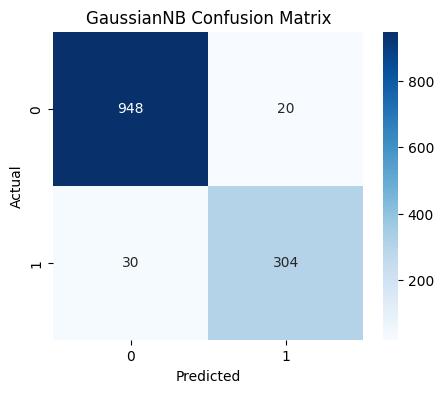

In [31]:
# Confusion matrix
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues')
plt.title("GaussianNB Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



In [32]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_gnb)
roc_auc = auc(fpr, tpr)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='GaussianNB'))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', line=dict(dash='dash'), name='Random'))
fig.update_layout(title=f"ROC Curve (AUC={roc_auc:.2f})", xaxis_title='FPR', yaxis_title='TPR')
fig.show()



In [33]:
# BernoulliNB on Binarized Purchase Flags
# Use top 20 items for demo
top_items = df_encoded['StockCode'].value_counts().head(20).index

basket_bin = (df_encoded[df_encoded['StockCode'].isin(top_items)]
              .groupby(['CustomerID', 'StockCode'])['Quantity']
              .sum().unstack().fillna(0))

basket_bin = basket_bin.applymap(lambda x: 1 if x>0 else 0)

# Align target
y_bin = rfm.set_index('CustomerID').loc[basket_bin.index,'HighValue']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(basket_bin, y_bin, test_size=0.3, random_state=42)

bnb = BernoulliNB()
bnb.fit(X_train_b, y_train_b)
y_pred_bnb = bnb.predict(X_test_b)
y_prob_bnb = bnb.predict_proba(X_test_b)[:,1]



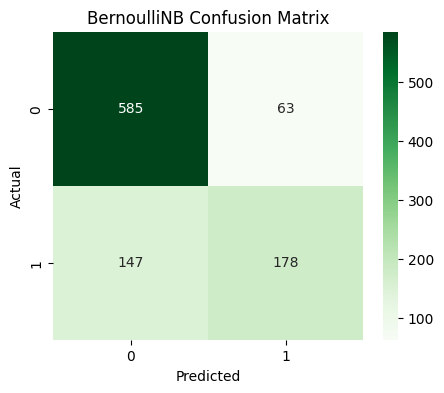

In [34]:
# Confusion matrix
cm_bnb = confusion_matrix(y_test_b, y_pred_bnb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Greens')
plt.title("BernoulliNB Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



In [35]:
# ROC Curve
fpr_b, tpr_b, _ = roc_curve(y_test_b, y_prob_bnb)
roc_auc_b = auc(fpr_b, tpr_b)

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=fpr_b, y=tpr_b, mode='lines', name='BernoulliNB'))
fig2.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', line=dict(dash='dash'), name='Random'))
fig2.update_layout(title=f"ROC Curve (AUC={roc_auc_b:.2f})", xaxis_title='FPR', yaxis_title='TPR')
fig2.show()



In [36]:

summary = pd.DataFrame({
    'Model':['GaussianNB (RFM)','BernoulliNB (Top Items)'],
    'Accuracy':[gnb.score(X_test, y_test), bnb.score(X_test_b, y_test_b)],
    'ROC_AUC':[roc_auc, roc_auc_b]
})

display(summary.style.background_gradient(cmap='Blues').set_caption("📌 Naïve Bayes Models Performance"))


,Model,Accuracy,ROC_AUC
0,GaussianNB (RFM),0.961598,0.988816
1,BernoulliNB (Top Items),0.784173,0.809753


## SVM

In [40]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Target: High Value Customers
threshold = rfm['Monetary'].quantile(0.75)
rfm['HighValue'] = (rfm['Monetary'] > threshold).astype(int)

# Features & scaling
X = rfm[['Recency','Frequency','Monetary']]
y = rfm['HighValue']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
rfm_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
rfm_pca['HighValue'] = y.values

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)


In [41]:
# SVM: Linear kernel
param_grid_linear = {'C':[0.1, 1, 10, 100]}
svc_linear = GridSearchCV(SVC(kernel='linear', probability=True), param_grid_linear, cv=5)
svc_linear.fit(X_train, y_train)
y_pred_linear = svc_linear.predict(X_test)
acc_linear = accuracy_score(y_test, y_pred_linear)

In [42]:
# SVM: RBF kernel
param_grid_rbf = {'C':[0.1,1,10], 'gamma':[0.01,0.1,1]}
svc_rbf = GridSearchCV(SVC(kernel='rbf', probability=True), param_grid_rbf, cv=5)
svc_rbf.fit(X_train, y_train)
y_pred_rbf = svc_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

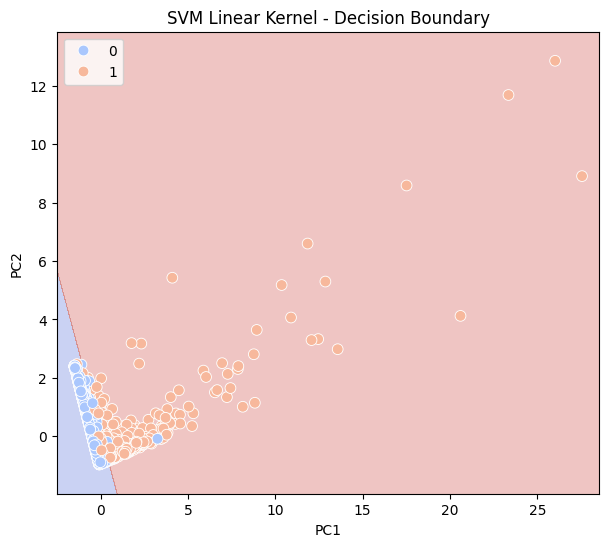

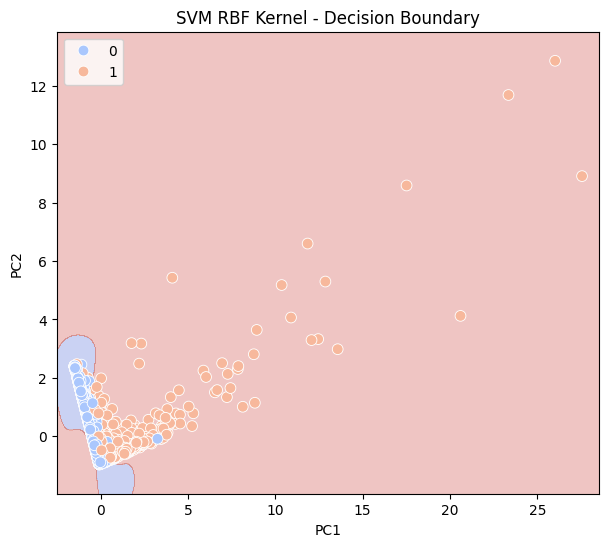

In [43]:
# Decision boundary visualization
def plot_decision_boundary(model, X, y, title):
    # Mesh grid
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min,x_max,0.01),
                         np.arange(y_min,y_max,0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette='coolwarm', s=60)
    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()

plot_decision_boundary(svc_linear.best_estimator_, X_pca, y.values, "SVM Linear Kernel - Decision Boundary")
plot_decision_boundary(svc_rbf.best_estimator_, X_pca, y.values, "SVM RBF Kernel - Decision Boundary")


In [44]:
summary_svm = pd.DataFrame({
    'Model': ['SVM Linear', 'SVM RBF'],
    'Best Parameters': [svc_linear.best_params_, svc_rbf.best_params_],
    'Test Accuracy': [acc_linear, acc_rbf]
})

fig_table = go.Figure(data=[go.Table(
    header=dict(values=["Model", "Best Parameters", "Test Accuracy"],
                fill_color='paleturquoise',
                align='center',
                font=dict(size=14, color='black')),
    cells=dict(values=[
                    summary_svm['Model'],
                    summary_svm['Best Parameters'].astype(str),
                    np.round(summary_svm['Test Accuracy'], 3)],
               fill_color='lavender',
               align='center',
               font=dict(size=12))
)])

fig_table.update_layout(title="📌 SVM Models Performance", title_x=0.5)
fig_table.show()

In [45]:
display(summary_svm.style.background_gradient(cmap='Blues').set_caption("📌 SVM Models Performance"))


,Model,Best Parameters,Test Accuracy
0,SVM Linear,{'C': 1},0.908602
1,SVM RBF,"{'C': 10, 'gamma': 1}",0.909370
